In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect('../data/processed/nyc_taxi.db', read_only=True)

# 1. Temporal Demand Patterns

## a. Trip demand by hour of day

In [6]:
df_hourly = con.execute("""
    SELECT 
        EXTRACT (HOUR FROM pickup_datetime) AS hour,
        COUNT(*) AS total_trip
    FROM fact_trip
    GROUP BY hour
    ORDER BY hour ASC
""").df()

df_hourly

,hour,total_trip
0,0,8849157
1,1,6184150
2,2,4431107
3,3,3564893
4,4,3698088
5,5,4309080
6,6,6674136
7,7,9988954
8,8,12060311
9,9,11134198


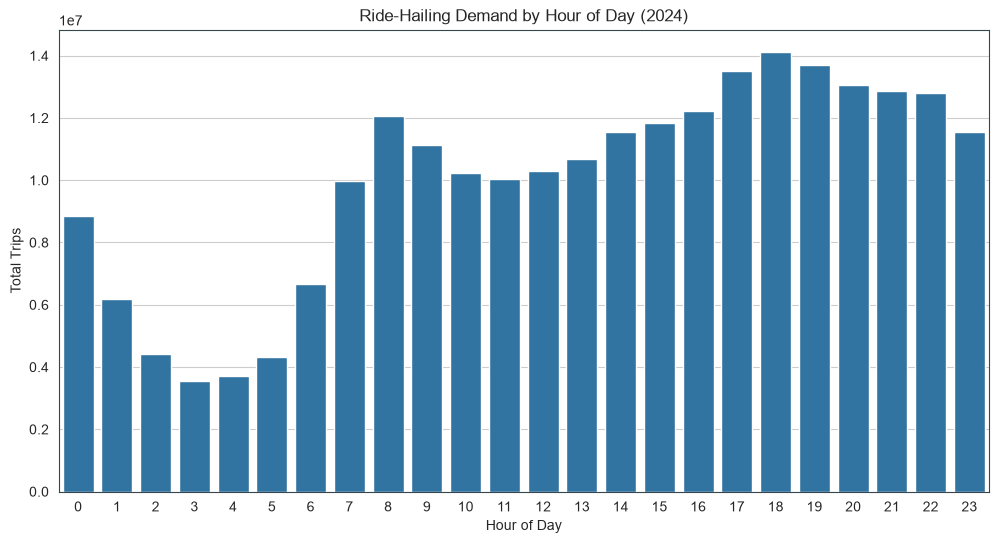

In [7]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_hourly, x='hour', y='total_trip')
plt.title('Ride-Hailing Demand by Hour of Day (2024)')
plt.xlabel('Hour of Day')
plt.ylabel('Total Trips')
plt.show()

## b. Trip demand by day of week

In [15]:
df_daily = con.execute("""
    SELECT 
        DAYNAME(pickup_datetime) AS day_name,
        ISODOW(pickup_datetime) AS day_number,
        COUNT(*) AS total_trip
    FROM fact_trip
    GROUP BY day_name, day_number
    ORDER BY day_number ASC
""").df()

df_daily

,day_name,day_number,total_trip
0,Monday,1,29837758
1,Tuesday,2,31253099
2,Wednesday,3,32449417
3,Thursday,4,34194929
4,Friday,5,37380620
5,Saturday,6,40006461
6,Sunday,7,34304014


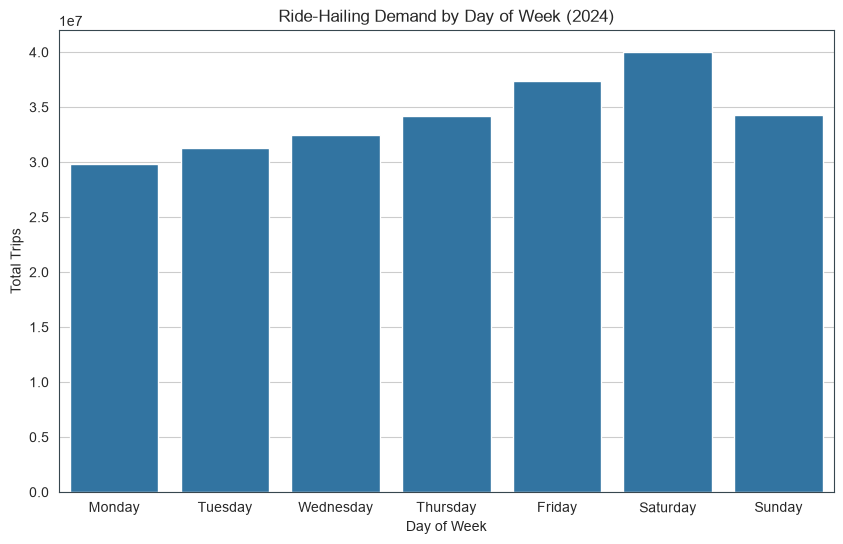

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_daily, x='day_name', y='total_trip')
plt.title('Ride-Hailing Demand by Day of Week (2024)')
plt.xlabel('Day of Week')
plt.ylabel('Total Trips')
plt.show()

## c. Trip demand weekday vs weekend

In [16]:
df_weekend = con.execute("""
    SELECT 
        t.is_weekend,
        COUNT(*) AS total_trip,
        COUNT(*) * 1.0 / COUNT(DISTINCT t.day_id) AS avg_trip_per_day
    FROM fact_trip f
    JOIN dim_time t ON DATE_TRUNC('hour', f.pickup_datetime) = t.time_id
    GROUP BY t.is_weekend
""").df()

df_weekend

,is_weekend,total_trip,avg_trip_per_day
0,0,165115823,630213.064885
1,1,74310475,714523.798077


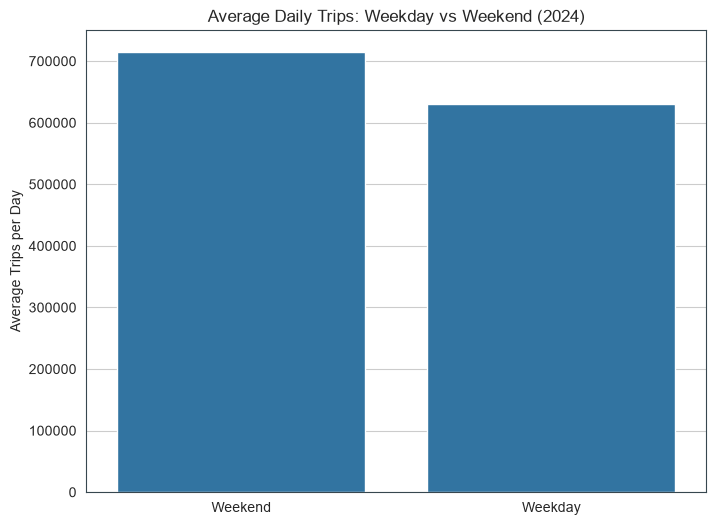

In [12]:
df_weekend['label'] = df_weekend['is_weekend'].map({0: 'Weekday', 1: 'Weekend'})

plt.figure(figsize=(8, 6))
sns.barplot(data=df_weekend, x='label', y='avg_trip_per_day')
plt.title('Average Daily Trips: Weekday vs Weekend (2024)')
plt.xlabel('')
plt.ylabel('Average Trips per Day')
plt.show()

# 2. Spatial Demand Patterns

## a. Demand per pickup borough

In [17]:
df_borough = con.execute("""
    SELECT
        z.Borough AS pickup_borough,
        COUNT(*) AS total_trip
    FROM fact_trip AS f
    JOIN dim_zone AS z ON f.PULocationID = z.LocationID
    GROUP BY pickup_borough
    ORDER BY total_trip DESC
""").df()

df_borough

,pickup_borough,total_trip
0,Manhattan,93072562
1,Brooklyn,63160869
2,Queens,50089862
3,Bronx,29568380
4,Staten Island,3525180
5,N/A,9430
6,EWR,15


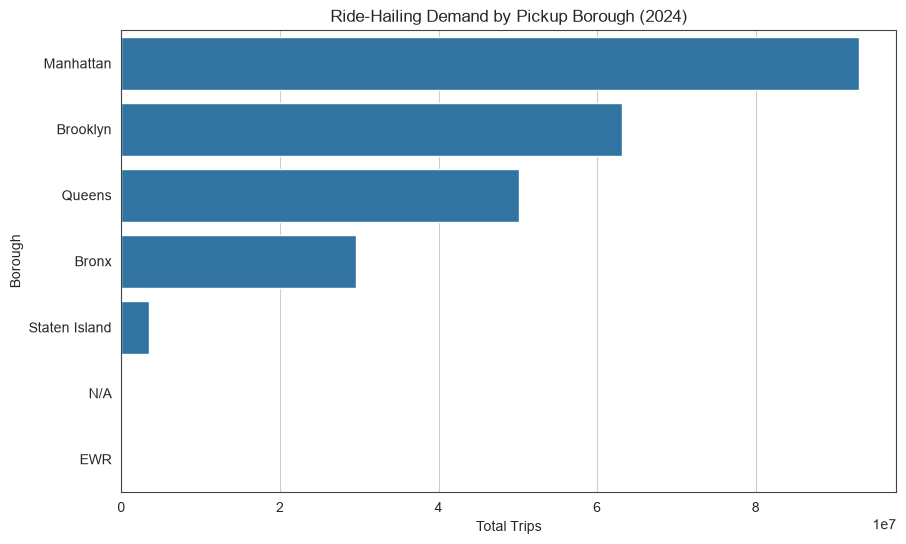

In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_borough, x='total_trip', y='pickup_borough')
plt.title('Ride-Hailing Demand by Pickup Borough (2024)')
plt.xlabel('Total Trips')
plt.ylabel('Borough')
plt.show()

## b. Top 10 rute pickup→dropoff (borough level)

In [18]:
df_route = con.execute("""
    SELECT
        pu.Borough AS pickup_borough,
        dropoff.Borough AS dropoff_borough,
        COUNT(*) AS total_trip
    FROM fact_trip AS f
    JOIN dim_zone AS pu ON f.PULocationID = pu.LocationID
    JOIN dim_zone AS dropoff ON f.DOLocationID = dropoff.LocationID
    GROUP BY pickup_borough, dropoff_borough
    ORDER BY total_trip DESC
    LIMIT 10
""").df()

df_route

,pickup_borough,dropoff_borough,total_trip
0,Manhattan,Manhattan,64532237
1,Brooklyn,Brooklyn,47533964
2,Queens,Queens,32226154
3,Bronx,Bronx,21528939
4,Manhattan,Queens,9146661
5,Manhattan,Brooklyn,8215943
6,Queens,Manhattan,7460269
7,Brooklyn,Manhattan,7266278
8,Brooklyn,Queens,6862270
9,Queens,Brooklyn,6149204


# 3. Trip Distance and Duration Distribution

## a. Average & maximum distance by day

In [19]:
df_distance = con.execute("""
    SELECT 
        DAYNAME(pickup_datetime) AS day_name,
        ISODOW(pickup_datetime) AS day_number,
        AVG(trip_miles) AS avg_distance,
        MAX(trip_miles) AS max_distance
    FROM fact_trip
    GROUP BY day_name, day_number
    ORDER BY day_number ASC
""").df()

df_distance

,day_name,day_number,avg_distance,max_distance
0,Monday,1,5.215818,469.408
1,Tuesday,2,4.972753,555.250
2,Wednesday,3,5.004116,373.730
3,Thursday,4,5.123656,286.210
4,Friday,5,4.964994,455.520
5,Saturday,6,4.950952,490.310
6,Sunday,7,5.377765,363.550


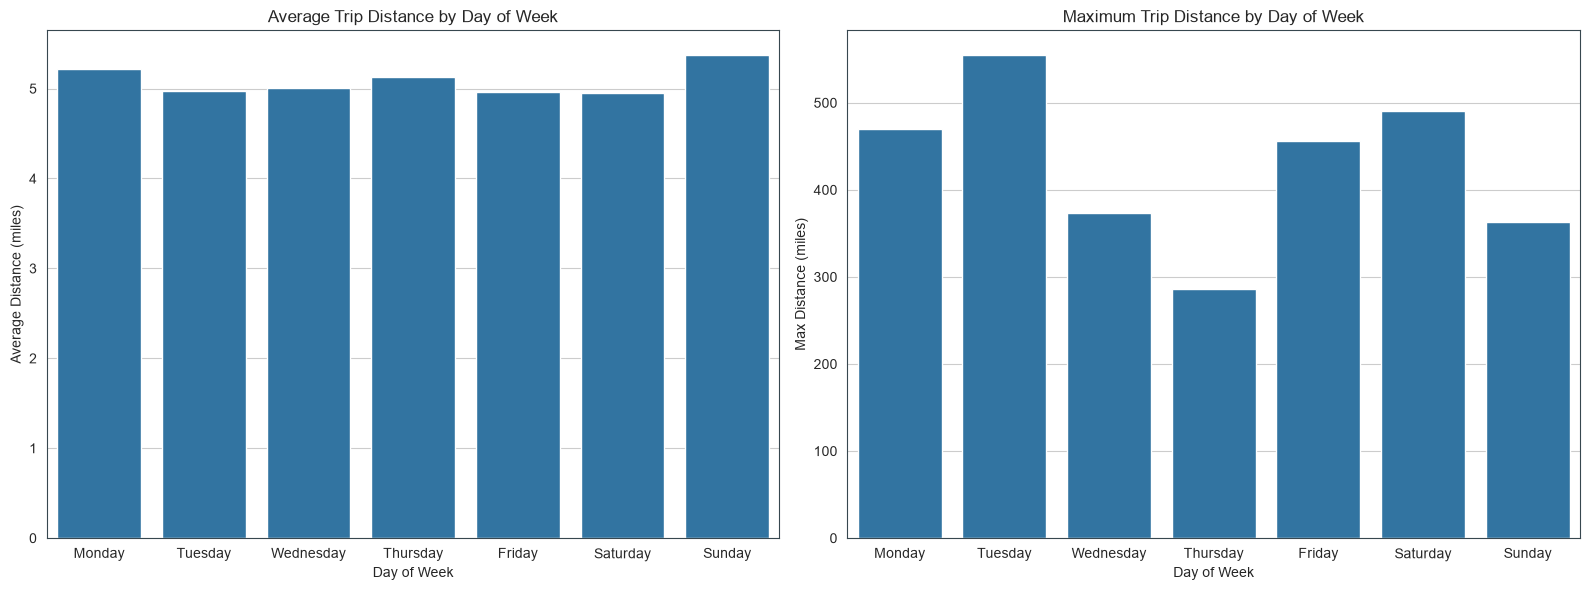

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=df_distance, x='day_name', y='avg_distance', ax=axes[0])
axes[0].set_title('Average Trip Distance by Day of Week')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Average Distance (miles)')

sns.barplot(data=df_distance, x='day_name', y='max_distance', ax=axes[1])
axes[1].set_title('Maximum Trip Distance by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Max Distance (miles)')

plt.tight_layout()
plt.show()

## b. Average & maximum duration by day

In [22]:
df_duration = con.execute("""
    SELECT 
        DAYNAME(pickup_datetime) AS day_name,
        ISODOW(pickup_datetime) AS day_number,
        AVG(trip_time) AS avg_duration,
        MAX(trip_time) AS max_duration
    FROM fact_trip
    GROUP BY day_name, day_number
    ORDER BY day_number ASC
""").df()

df_duration

,day_name,day_number,avg_duration,max_duration
0,Monday,1,1185.626344,41560
1,Tuesday,2,1214.500065,52060
2,Wednesday,3,1238.429510,55138
3,Thursday,4,1273.464356,43666
4,Friday,5,1230.327415,35729
5,Saturday,6,1173.109386,43234
6,Sunday,7,1142.367963,43234


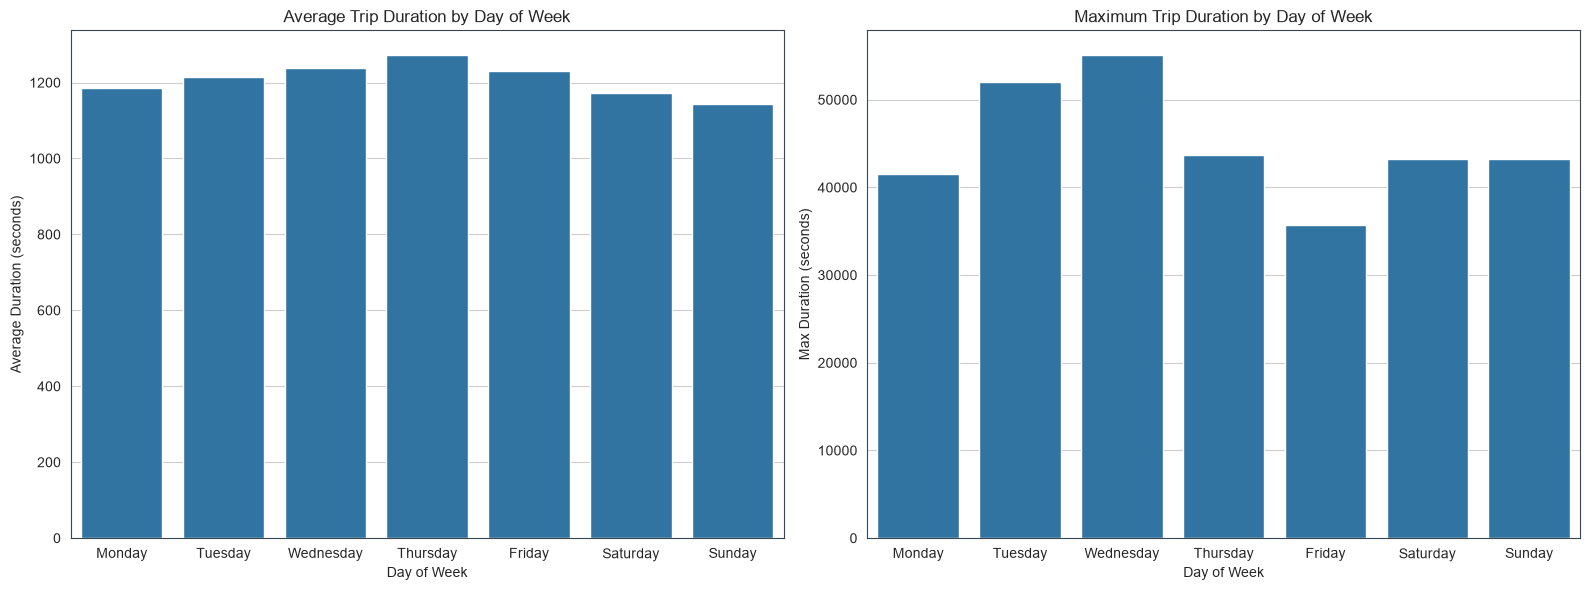

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=df_duration, x='day_name', y='avg_duration', ax=axes[0])
axes[0].set_title('Average Trip Duration by Day of Week')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Average Duration (seconds)')

sns.barplot(data=df_duration, x='day_name', y='max_duration', ax=axes[1])
axes[1].set_title('Maximum Trip Duration by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Max Duration (seconds)')

plt.tight_layout()
plt.show()

# 4. Zone Volatily

In [24]:
df_zone_daily = con.execute("""
    SELECT 
        f.PULocationID,
        DATE_TRUNC('day', f.pickup_datetime) AS trip_date,
        COUNT(*) AS daily_trip
    FROM fact_trip f
    GROUP BY f.PULocationID, trip_date
""").df()

df_volatility = df_zone_daily.groupby('PULocationID')['daily_trip'].agg(['mean', 'std']).reset_index()
df_volatility['cv'] = df_volatility['std'] / df_volatility['mean']
df_volatility = df_volatility.merge(
    con.execute("SELECT LocationID, Zone, Borough FROM dim_zone").df(),
    left_on='PULocationID', right_on='LocationID'
)

df_volatility_ranked = df_volatility.sort_values('cv', ascending=False)

print("Top 10 Most Volatile Zones (highest CV):")
print(df_volatility_ranked[['Zone', 'Borough', 'mean', 'std', 'cv']].head(10))

print("\nTop 10 Most Stable Zones (lowest CV):")
print(df_volatility_ranked[['Zone', 'Borough', 'mean', 'std', 'cv']].tail(10))

Top 10 Most Volatile Zones (highest CV):
                                    Zone        Borough        mean  \
26   Breezy Point/Fort Tilden/Riis Beach         Queens   50.631148   
92          Flushing Meadows-Corona Park         Queens  525.866120   
250                        Willets Point         Queens   25.409836   
7                           Astoria Park         Queens   27.226776   
191                      Randalls Island      Manhattan  112.338798   
29                         Broad Channel         Queens   39.573770   
107                     Great Kills Park  Staten Island    1.964143   
1                            Jamaica Bay         Queens    2.141700   
33                    Brooklyn Navy Yard       Brooklyn  623.874317   
187                        Prospect Park       Brooklyn  396.879781   

            std        cv  
26    64.615855  1.276208  
92   524.865865  0.998098  
250   19.368703  0.762252  
7     19.626385  0.720849  
191   78.265932  0.696695  
29    24.

# 5. Supply-Demand Proxy

In [27]:
df_utilization_proxy = con.execute("""
    SELECT 
        f.PULocationID,
        DATE_TRUNC('day', f.pickup_datetime) AS trip_date,
        SUM(f.trip_time) AS total_occupied_seconds,
        COUNT(*) AS total_trip
    FROM fact_trip f
    GROUP BY f.PULocationID, trip_date
""").df()

df_utilization_proxy['occupied_hours'] = df_utilization_proxy['total_occupied_seconds'] / 3600
df_utilization_proxy['utilization_proxy_pct'] = (df_utilization_proxy['occupied_hours'] / 24) * 100

df_utilization_summary = df_utilization_proxy.groupby('PULocationID').agg(
    avg_occupied_hours_per_day=('occupied_hours', 'mean'),
    avg_daily_trip=('total_trip', 'mean')
).reset_index()

df_utilization_summary = df_utilization_summary.merge(
    con.execute("SELECT LocationID, Zone, Borough FROM dim_zone").df(),
    left_on='PULocationID', right_on='LocationID'
)

df_utilization_summary.sort_values('avg_occupied_hours_per_day', ascending=False).head(10)

,PULocationID,avg_occupied_hours_per_day,avg_daily_trip,LocationID,Zone,Borough
129,132,8795.414224,11831.644809,132,JFK Airport,Queens
135,138,7450.460741,12945.762295,138,LaGuardia Airport,Queens
227,230,3338.624389,8032.139344,230,Times Sq/Theatre District,Manhattan
158,161,3036.599113,7662.841530,161,Midtown Center,Manhattan
67,68,2895.531000,7344.439891,68,East Chelsea,Manhattan
78,79,2842.340972,8665.300546,79,East Village,Manhattan
60,61,2709.123331,8568.901639,61,Crown Heights North,Brooklyn
228,231,2637.524692,7413.587432,231,TriBeCa/Civic Center,Manhattan
161,164,2569.831277,6890.680328,164,Midtown South,Manhattan
243,246,2568.983890,7022.568306,246,West Chelsea/Hudson Yards,Manhattan


**Catatan Keterbatasan:** Metrik ini adalah **total jam trip gabungan** (occupied hours) per zona per hari — BUKAN utilization rate dalam arti sebenarnya (occupied time ÷ available driver-time), karena dataset tidak memiliki data jumlah driver aktif per zona. Angka besar di suatu zona mencerminkan tingginya volume aktivitas trip paralel (banyak kendaraan beroperasi bersamaan), bukan efisiensi individual driver. Proxy ini juga tidak menangkap permintaan yang ditolak/dibatalkan/tidak terlayani.